In [1]:
!pip install pandas
!pip install seaborn
!pip install matplotlib
!pip install numpy
!pip install pandas
!pip install scikit-learn
!pip install mysql-connector-python

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [2]:
import sys
sys.path.append(r"C:\Users\anand\AppData\Roaming\Python\Python313\site-packages")

import mysql.connector
print("Connected successfully")

Connected successfully


In [3]:
import pandas as pd
import mysql.connector
import os

# List of CSV files and their corresponding table names
csv_files = [
    ('customers.csv', 'customers'),
    ('orders.csv', 'orders'),
    ('sellers.csv', 'sellers'),
    ('products.csv', 'products'),
    ('geolocation.csv', 'geolocation'),
    ('payments.csv', 'payments'),
    ('order_items.csv', 'order_items')  
    
    # Added payments.csv for specific handling
]

# Connect to the MySQL database
conn = mysql.connector.connect(
    host='localhost',
    port=3306,
    user='root',
    password='12345',
    database='ecommerce'
)
cursor = conn.cursor()

# Folder containing the CSV files
folder_path = r'C:/Users/anand/OneDrive/Desktop/DATA analytics model/PROJECT 1/Ecommerce'

def get_sql_type(dtype):
    if pd.api.types.is_integer_dtype(dtype):
        return 'INT'
    elif pd.api.types.is_float_dtype(dtype):
        return 'FLOAT'
    elif pd.api.types.is_bool_dtype(dtype):
        return 'BOOLEAN'
    elif pd.api.types.is_datetime64_any_dtype(dtype):
        return 'DATETIME'
    else:
        return 'TEXT'

for csv_file, table_name in csv_files:
    file_path = os.path.join(folder_path, csv_file)

    # Read the CSV file into a pandas DataFrame
    df = pd.read_csv(file_path)

    # Replace NaN with None to handle SQL NULL
    df = df.where(pd.notnull(df), None)

    # Debugging: Check for NaN values
    print(f"Processing {csv_file}")
    print(f"NaN values before replacement:\n{df.isnull().sum()}\n")

    # Clean column names
    df.columns = [col.replace(' ', '_').replace('-', '_').replace('.', '_') for col in df.columns]

    # Generate the CREATE TABLE statement with appropriate data types
    columns = ', '.join([f'`{col}` {get_sql_type(df[col].dtype)}' for col in df.columns])
    create_table_query = f'CREATE TABLE IF NOT EXISTS `{table_name}` ({columns})'
    cursor.execute(create_table_query)

    # Insert DataFrame data into the MySQL table
    for _, row in df.iterrows():
        # Convert row to tuple and handle NaN/None explicitly
        values = tuple(None if pd.isna(x) else x for x in row)
        sql = f"INSERT INTO `{table_name}` ({', '.join(['`' + col + '`' for col in df.columns])}) VALUES ({', '.join(['%s'] * len(row))})"
        cursor.execute(sql, values)

    # Commit the transaction for the current CSV file
    conn.commit()

# Close the connection
conn.close()

Processing customers.csv
NaN values before replacement:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Processing orders.csv
NaN values before replacement:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Processing sellers.csv
NaN values before replacement:
seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

Processing products.csv
NaN values before replacement:
product_id                      0
product category              610
product_name_length           610
product_description_length    610
product_photos_qty            610
prod

In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector
import numpy as np

db = mysql.connector.connect(host = 'localhost',
                             username = 'root',
                             password = '12345',
                             database = 'ecommerce')
cur = db.cursor()


#list all unique cities where customers are located.

In [71]:
query = """ select distinct(customer_city) from customers """

cur.execute(query)

data = cur.fetchall()

df =pd.DataFrame(data,columns=["Cities"])
df.head()

,Cities
0,franca
1,sao bernardo do campo
2,sao paulo
3,mogi das cruzes
4,campinas


In [72]:

#2. Count the number of orders placed in 2017

In [73]:
query = """ select count(order_id) from orders where year(order_purchase_timestamp)=2017"""

cur.execute(query)

data = cur.fetchall()

print("total number of order in 2017 is" , data [0][0])

total number of order in 2017 is 45101


In [74]:
#find total sales per category

In [75]:
query = """ SELECT 
    upper(products.product_category) category,
    round(SUM(payments.payment_value),2) sales
FROM
    products
        JOIN
    order_items ON products.product_id = order_items.product_id
      JOIN
    payments ON order_items.order_id = payments.order_id
GROUP BY category """

cur.execute(query)

data = cur.fetchall()

df =pd.DataFrame(data,columns=["category","sales"])
df

,category,sales
0,PERFUMERY,506738.66
1,FURNITURE DECORATION,1430176.39
2,TELEPHONY,486882.05
3,BED TABLE BATH,1712553.67
4,AUTOMOTIVE,852294.33
...,...,...
69,CDS MUSIC DVDS,1199.43
70,LA CUISINE,2913.53
71,FASHION CHILDREN'S CLOTHING,785.67
72,PC GAMER,2174.43


In [76]:
#calculate the percentage of orders that were paid in installments

In [77]:
query = """ select (sum(case when payment_installments >=1
 then 1 else 0 end))/count(*)*100 from payments
 """ 

cur.execute(query)

data = cur.fetchall()

"this percentage of payments is in installment",data [0][0]

('this percentage of payments is in installment', Decimal('99.9981'))

In [78]:
#count no. of customers in each state

In [79]:
query = """ select Customer_state state ,count(customer_id) from customers group by customer_state
order by count(customer_id) desc """ 

cur.execute(query)

data = cur.fetchall()

dx = pd.DataFrame(data,columns=("state","number of customers"))
dx

,state,number of customers
0,SP,41746
1,RJ,12852
2,MG,11635
3,RS,5466
4,PR,5045
5,SC,3637
6,BA,3380
7,DF,2140
8,ES,2033
9,GO,2020


<function matplotlib.pyplot.show(close=None, block=None)>

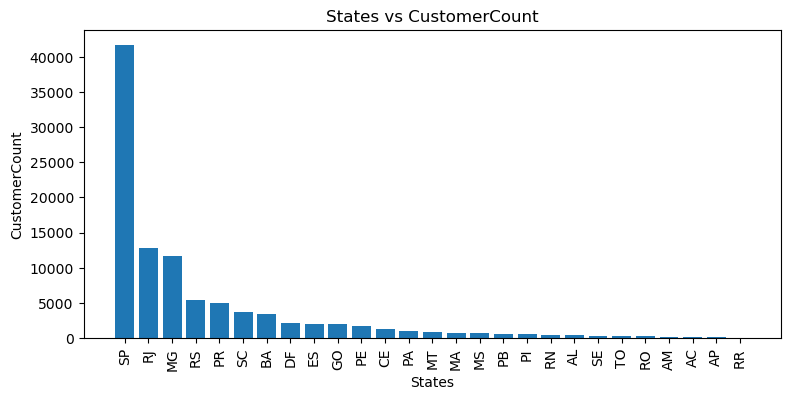

In [80]:
query = """ select Customer_state state ,
       count(customer_id) 
       from customers 
       group by customer_state
""" 

cur.execute(query)

data = cur.fetchall()

dx = pd.DataFrame(data,columns=(["state","number_of_customers"]))
dx =dx.sort_values(by= "number_of_customers",ascending= 0 )

plt.figure(figsize = (9,4))
plt.bar(dx["state"],dx["number_of_customers"])
plt.xticks(rotation=90)
plt.xlabel("States")
plt.ylabel("CustomerCount")
plt.title("States vs CustomerCount")
plt.show


In [81]:
#INTERMEDIATE QUERIES

In [82]:

#CALCULATE THE NUMBER OF ORDERS PER MONTH IN 2018

In [83]:
query = """ select MONTHNAME(order_purchase_timestamp) Months,count(order_id) No_of_orders
 from orders where YEAR(order_purchase_timestamp) = 2018
 group by Months
""" 

cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data,columns =["Months","No_of_orders"])
df

,Months,No_of_orders
0,July,6292
1,August,6512
2,February,6728
3,June,6167
4,March,7211
5,January,7269
6,May,6873
7,April,6939
8,September,16
9,October,4


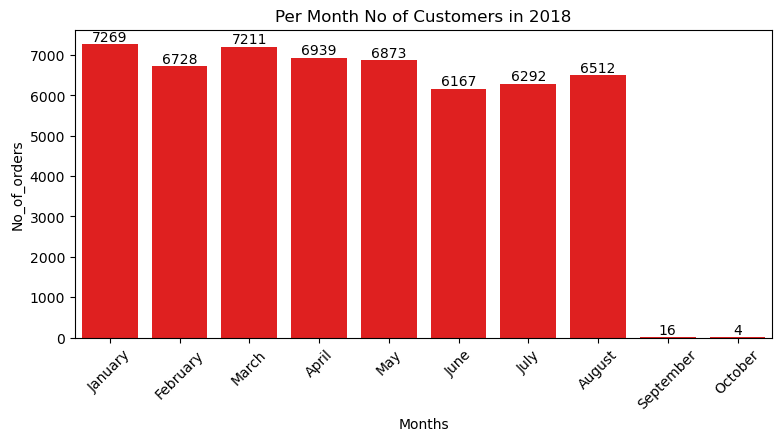

In [84]:
query = """ select MONTHNAME(order_purchase_timestamp) Months,count(order_id) No_of_orders
 from orders where YEAR(order_purchase_timestamp) = 2018
 group by Months
""" 

cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data,columns =["Months","No_of_orders"])
plt.figure(figsize = (9,4))

o = ["January","February","March","April","May","June","July","August","September","October"]
ax=sns.barplot(x = df["Months"],y = df["No_of_orders"],data = df, order = o,color = "red" )
ax.bar_label(ax.containers[0])
plt.title("Per Month No of Customers in 2018")
plt.xticks(rotation=45)
plt.show()

#Find the average number of products  per order, grouped by customer city.

In [85]:
query = """
WITH count_per_order AS 
(
    SELECT 
        orders.order_id,
        orders.customer_id,
        COUNT(order_items.order_id) AS oc
    FROM orders
    JOIN order_items 
        ON orders.order_id = order_items.order_id
    GROUP BY orders.customer_id, orders.order_id
)

SELECT 
    customers.customer_city, 
    ROUND(AVG(count_per_order.oc), 2) AS average_order
FROM customers 
JOIN count_per_order
    ON customers.customer_id = count_per_order.customer_id
GROUP BY customers.customer_city
"""

cur.execute(query)

data = cur.fetchall()
df =pd.DataFrame(data,columns=["city","average order"])
df

,city,average order
0,sao paulo,1.16
1,sao jose dos campos,1.14
2,porto alegre,1.17
3,indaial,1.12
4,treze tilias,1.27
...,...,...
4105,buriti,3.00
4106,morro agudo de goias,1.00
4107,santa filomena,1.00
4108,guamiranga,1.00


In [86]:
#Calculate the percentage of total revenue contributed by each product category

In [87]:
query = """ SELECT 
    UPPER(products.product_category) category,
    ROUND((SUM(payments.payment_value) / (SELECT 
                    SUM(payment_value)FROM
                    payments) * 100),2) sales
FROM
    products
        JOIN
    order_items ON products.product_id = order_items.product_id
        JOIN
    payments ON order_items.order_id = payments.order_id
GROUP BY category order by sales desc """

cur.execute(query)

data = cur.fetchall()

df =pd.DataFrame(data,columns=["category","sales percentage"])
df


,category,sales percentage
0,BED TABLE BATH,10.70
1,HEALTH BEAUTY,10.35
2,COMPUTER ACCESSORIES,9.90
3,FURNITURE DECORATION,8.93
4,WATCHES PRESENT,8.93
...,...,...
69,HOUSE COMFORT 2,0.01
70,CDS MUSIC DVDS,0.01
71,PC GAMER,0.01
72,FASHION CHILDREN'S CLOTHING,0.00


In [88]:
#Indentify the correlation between product price and the number of times a product has been purchased


In [89]:
query = """ SELECT 
    UPPER(products.product_category),
    ROUND(AVG(order_items.price), 2),
    COUNT(order_items.product_id) AS number_of_product
FROM
    products
        JOIN
    order_items ON order_items.product_id = products.product_id
GROUP BY products.product_category """

cur.execute(query)

data = cur.fetchall()

df =pd.DataFrame(data,columns=["category","avg price","Order_count"])



In [90]:
query = """ SELECT 
    UPPER(products.product_category),
    ROUND(AVG(order_items.price), 2),
    COUNT(order_items.product_id) AS number_of_product
FROM
    products
        JOIN
    order_items ON order_items.product_id = products.product_id
GROUP BY products.product_category """

cur.execute(query)

data = cur.fetchall()

df =pd.DataFrame(data,columns=["category","avg price","Order_count"])
arr1 =df["avg price"]
arr2 = df["Order_count"]
a= np.corrcoef([arr1,arr2])
print(a)
print(" no significant of price on order count as correlation is ",a[0][1])

#no significant of price on order count as correlation is -0.0106 there is neutral relationship between them 
# correlation exist between -1 to +1
# -1 means inversely propostional 
# +1 directly propotional


[[ 1.         -0.10631514]
 [-0.10631514  1.        ]]
 no significant of price on order count as correlation is  -0.10631514167157562


In [91]:
#Calculate the total revenue generated by each seller , and rank them by revenue

In [93]:
query = """ select * , dense_rank() over(order by revenue desc) 
as rn from (SELECT 
    order_items.seller_id, 
    round(SUM(payments.payment_value),2) revenue
FROM
    order_items
        JOIN
    payments ON order_items.order_id = payments.order_id
GROUP BY order_items.seller_id) as a
"""

cur.execute(query)

data = cur.fetchall()
df =pd.DataFrame(data,columns=["Seller_id","Revenue","Rank"])
df

,Seller_id,Revenue,Rank
0,7c67e1448b00f6e969d365cea6b010ab,507166.91,1
1,1025f0e2d44d7041d6cf58b6550e0bfa,308222.04,2
2,4a3ca9315b744ce9f8e9374361493884,301245.27,3
3,1f50f920176fa81dab994f9023523100,290253.42,4
4,53243585a1d6dc2643021fd1853d8905,284903.08,5
...,...,...,...
3090,ad14615bdd492b01b0d97922e87cb87f,19.21,3076
3091,702835e4b785b67a084280efca355756,18.56,3077
3092,4965a7002cca77301c82d3f91b82e1a9,16.36,3078
3093,77128dec4bec4878c37ab7d6169d6f26,15.22,3079


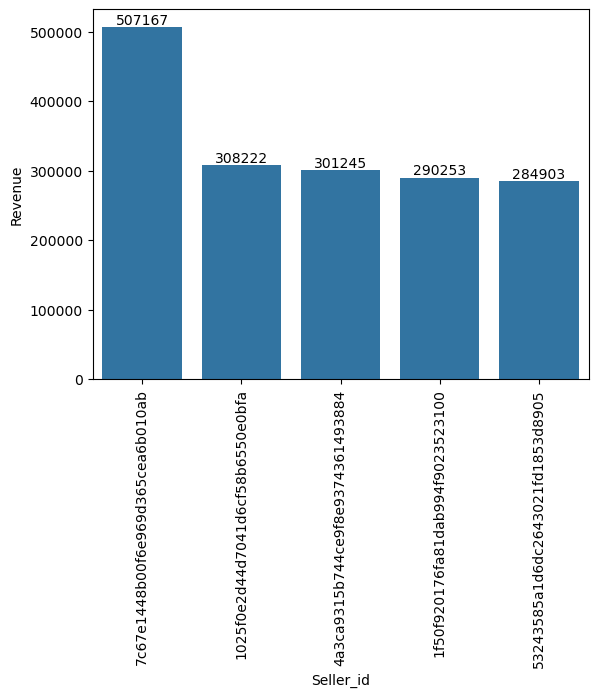

In [121]:
query = """ select * , dense_rank() over(order by revenue desc) 
as rn from (SELECT 
    order_items.seller_id, 
    round(SUM(payments.payment_value),2) revenue
FROM
    order_items
        JOIN
    payments ON order_items.order_id = payments.order_id
GROUP BY order_items.seller_id) as a
"""

cur.execute(query)

data = cur.fetchall()
df =pd.DataFrame(data,columns=["Seller_id","Revenue","Rank"])
df=df.head()
ax = sns.barplot(x ="Seller_id" , y = "Revenue", data = df)
plt.xticks(rotation = 90)
ax.bar_label(ax.containers[0])

plt.show()

# Calculate the moving average of the order values for each customer over their order history.

In [96]:
query = """ select customer_id ,order_purchase_timestamp, payment,
avg(payment) over(partition by customer_id 
order by order_purchase_timestamp rows between 2 preceding and current row ) as mov_avg 
from 

(select orders.customer_id , orders.order_purchase_timestamp,
payments.payment_value as payment
from payments join orders
on payments.order_id = orders.order_id) as a;
"""

cur.execute(query)

data = cur.fetchall()
df =pd.DataFrame(data,columns=["Customer_id","Order_purchase_timestamp","Payment","Moving_Average"])
df

,Customer_id,Order_purchase_timestamp,Payment,Moving_Average
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
1,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,67.41,67.410004
2,0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,195.42,195.419998
3,0002414f95344307404f0ace7a26f1d5,2017-08-16 13:09:20,179.35,179.350006
4,000379cdec625522490c315e70c7a9fb,2018-04-02 13:42:17,107.01,107.010002
...,...,...,...,...
103881,fffecc9f79fd8c764f843e9951b11341,2018-03-29 16:59:26,71.23,27.120001
103882,fffeda5b6d849fbd39689bb92087f431,2018-05-22 13:36:02,63.13,63.130001
103883,ffff42319e9b2d713724ae527742af25,2018-06-13 16:57:05,214.13,214.130005
103884,ffffa3172527f765de70084a7e53aae8,2017-09-02 11:53:32,45.50,45.500000


In [ ]:
# Calculate Cummulative Sales per month for each year

In [98]:
query = """ select  years, Months,payment,sum(payment) 
over(order by years, months) as cummulative_sales
from 
(select year(orders.order_purchase_timestamp) as years,
month(orders.order_purchase_timestamp) as Months, 
round(sum(payments.payment_value),2) as payment
from payments join orders
on payments.order_id = orders.order_id 
group by years , months order by  years ,months)  as a
"""

cur.execute(query)

data = cur.fetchall()
df =pd.DataFrame(data,columns=["Year","Month","Payment","Cummulative_Sales"])
df

,Year,Month,Payment,Cummulative_Sales
0,2016,9,252.24,252.24
1,2016,10,59090.48,59342.72
2,2016,12,19.62,59362.34
3,2017,1,138488.04,197850.38
4,2017,2,291908.01,489758.39
5,2017,3,449863.60,939621.99
6,2017,4,417788.03,1357410.02
7,2017,5,592918.82,1950328.84
8,2017,6,511276.38,2461605.22
9,2017,7,592382.92,3053988.14


In [ ]:
# Calculate year over year growth rate of total sales

In [105]:
query = """ select  years,payment,
((payment -(lag(payment,1)over(order by years)))
/(lag(payment,1)over(order by years)))*100
from 

(select year(orders.order_purchase_timestamp) as years, 
round(sum(payments.payment_value),2) as payment
from payments join orders
on payments.order_id = orders.order_id 
group by years order by  years )  as a;
"""

cur.execute(query)

data = cur.fetchall()
df =pd.DataFrame(data,columns=["Year","Payment","Sales Growth %"])
df

,Year,Payment,Sales Growth %
0,2016,59362.34,NaN
1,2017,7249746.73,12112.703761
2,2018,8699763.05,20.000924


In [ ]:
#Calculate the rentention rate of customers, defined as the percentage of customers who make another purchase within 6 months of their first purchasr

In [113]:
query = """with a as (select customers.customer_id,
 min(orders.order_purchase_timestamp) first_order
 from customers join orders
 on customers.customer_id = orders.customer_id
 group by customer_id ),
b as
(select a.customer_id,count(distinct orders.order_purchase_timestamp)
from a join orders on orders.customer_id = a.customer_id
and orders.order_purchase_timestamp > first_order 
and order_purchase_timestamp < date_add(first_order,interval 6 month) group by customer_id) 

select (100*(count(distinct a.customer_id))/count(distinct b.customer_id))  as repeated_customer
from a left join b on a.customer_id = b.customer_id;
"""

cur.execute(query)

data = cur.fetchall()
data

[(None,)]

In [ ]:
#Identify the top 3 customers who spent the most money in each year

In [114]:
query = """select years ,customer_id ,payment,drank 
from
(select year(orders.order_purchase_timestamp) years,
orders.customer_id , 
sum(payments.payment_value) payment,
dense_rank()over (partition by year(orders.order_purchase_timestamp) 
 order by sum(payments.payment_value) desc) drank
from orders join payments
on payments.order_id =orders.order_id
group by year(orders.order_purchase_timestamp) , orders.customer_id) as a
 where drank <= 3 ;  
"""

cur.execute(query)

data = cur.fetchall()
df =pd.DataFrame(data,columns=["Year","Customer_Id","Payment","Rank of customer"])
df


,Year,Customer_Id,Payment,Rank of customer
0,2016,a9dc96b027d1252bbac0a9b72d837fc6,1423.550049,1
1,2016,1d34ed25963d5aae4cf3d7f3a4cda173,1400.739990,2
2,2016,4a06381959b6670756de02e07b83815f,1227.780029,3
3,2017,1617b1357756262bfa56ab541c47bc16,13664.080078,1
4,2017,c6e2731c5b391845f6800c97401a43a9,6929.310059,2
5,2017,3fd6777bbce08a352fddd04e4a7cc8f6,6726.660156,3
6,2018,ec5b2ba62e574342386871631fafd3fc,7274.879883,1
7,2018,f48d464a0baaea338cb25f816991ab1f,6922.209961,2
8,2018,e0a2412720e9ea4f26c1ac985f6a7358,4809.439941,3


<function matplotlib.pyplot.show(close=None, block=None)>

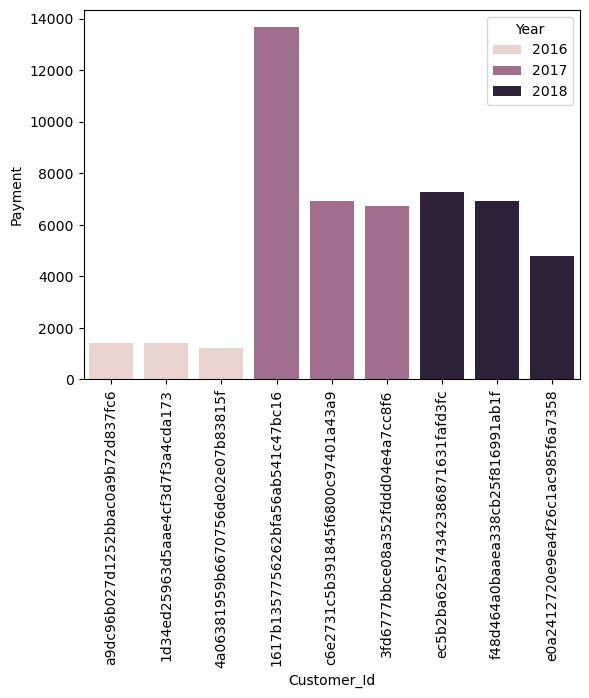

In [120]:
query = """select years ,customer_id ,payment,drank 
from
(select year(orders.order_purchase_timestamp) years,
orders.customer_id , 
sum(payments.payment_value) payment,
dense_rank()over (partition by year(orders.order_purchase_timestamp) 
 order by sum(payments.payment_value) desc) drank
from orders join payments
on payments.order_id =orders.order_id
group by year(orders.order_purchase_timestamp) , orders.customer_id) as a
 where drank <= 3 ;  
"""

cur.execute(query)

data = cur.fetchall()
df =pd.DataFrame(data,columns=["Year","Customer_Id","Payment","Rank of customer"])
sns.barplot(x="Customer_Id" ,y="Payment" , data =df , hue = "Year")
plt.xticks(rotation =90)
plt.show
